In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen, VerticalPitch


c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Liuhy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
parser = Sbopen()
competitions = parser.competition()
competitions

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
75,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2026-04-11T12:48:10.012987,2021-06-13T16:17:31.694,NaN,2026-04-11T12:48:10.012987
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896
78,72,107,International,Women's World Cup,female,False,True,2023,2026-05-03T13:51:31.021141,2026-05-03T13:55:52.303219,2026-05-03T13:55:52.303219,2026-05-03T13:51:31.021141


In [4]:
competitions['competition_name'].unique()

<ArrowStringArray>
[          '1. Bundesliga',  'African Cup of Nations',
        'Champions League',            'Copa America',
            'Copa del Rey', 'FA Women's Super League',
      'FIFA U20 World Cup',          'FIFA World Cup',
       'Frauen Bundesliga',     'Indian Super league',
                 'La Liga',                  'Liga F',
        'Liga Profesional',                 'Ligue 1',
     'Major League Soccer',   'North American League',
                    'NWSL',          'Premier League',
                 'Serie A',           'Serie A Women',
               'UEFA Euro',      'UEFA Europa League',
       'UEFA Women's Euro',       'Women's World Cup']
Length: 24, dtype: str

In [5]:
match = parser.match(competition_id =16, season_id =41)
match.columns

Index(['match_id', 'match_date', 'kick_off', 'home_score', 'away_score',
       'match_status', 'match_status_360', 'last_updated', 'last_updated_360',
       'match_week', 'competition_id', 'country_name', 'competition_name',
       'season_id', 'season_name', 'home_team_id', 'home_team_name',
       'home_team_gender', 'home_team_group', 'home_team_country_id',
       'home_team_country_name', 'home_team_managers_id',
       'home_team_managers_name', 'home_team_managers_nickname',
       'home_team_managers_dob', 'home_team_managers_country_id',
       'home_team_managers_country_name', 'away_team_id', 'away_team_name',
       'away_team_gender', 'away_team_group', 'away_team_country_id',
       'away_team_country_name', 'away_team_managers_id',
       'away_team_managers_name', 'away_team_managers_nickname',
       'away_team_managers_dob', 'away_team_managers_country_id',
       'away_team_managers_country_name', 'metadata_data_version',
       'metadata_shot_fidelity_version', 'm

In [10]:
match[['match_date', 'home_team_name', 'home_score', 'away_score', 'away_team_name', 'competition_stage_name', 
       'stadium_name', 'stadium_country_name']]


,match_date,home_team_name,home_score,away_score,away_team_name,competition_stage_name,stadium_name,stadium_country_name
0,2009-05-27,Barcelona,2,0,Manchester United,Final,Estadio Olímpico,Italy


In [11]:
match.match_id

0    3750201
Name: match_id, dtype: int64

In [16]:
df, df_related, df_freeze, df_tactics = parser.event(3750201)


In [17]:
passes = df.loc[df['type_name'] == 'Pass'].loc[df['sub_type_name'] != 'Throw-in'].set_index('id')
passes.head()

,index,period,timestamp,minute,second,possession,duration,match_id,type_id,type_name,...,block_offensive,foul_committed_card_id,foul_committed_card_name,substitution_replacement_id,substitution_replacement_name,shot_one_on_one,pass_no_touch,pass_miscommunication,dribble_no_touch,injury_stoppage_in_chain
id,,,,,,,,,,,,,,,,,,,,,
6dd66800-5339-44c3-b3dd-c6d4a4500eb1,5,1,00:00:00.515000,0,0,2,0.169491,3750201,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
519a021c-3966-4856-9659-a290c4279926,8,1,00:00:00.724000,0,0,2,1.111525,3750201,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
705fbd42-47f8-4bd8-9ba1-2ef95eda4ca8,11,1,00:00:02.051000,0,2,2,1.566512,3750201,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bce0d7a3-987e-45d4-b3ee-0de597ec3bdf,14,1,00:00:03.657000,0,3,2,1.806347,3750201,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9c54c35e-f31b-4c68-a47a-e78adf3db904,17,1,00:00:05.504000,0,5,2,1.397799,3750201,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df['player_name'].value_counts().head(10)

player_name
Xavier Hernández Creus            257
Lionel Andrés Messi Cuccittini    255
Andrés Iniesta Luján              248
Michael Carrick                   202
Carles Puyol i Saforcada          168
Nemanja Vidić                     167
Sergio Busquets i Burgos          162
Sylvio Mendes Campos Junior       160
Wayne Mark Rooney                 159
Rio Ferdinand                     157
Name: count, dtype: int64

In [20]:
# Define a boolean mask to filter Messi's passes
messi_stats_filter = (df['player_name'] == "Lionel Andrés Messi Cuccittini")

# Filter the DataFrame for Messi's passes and "Success" outcomes
messi_pass = df[messi_stats_filter & (df['type_name'] == 'Pass')]

messi_pass['outcome_name'].unique(), messi_pass['outcome_name'].value_counts() 

(<ArrowStringArray>
 [nan, 'Incomplete']
 Length: 2, dtype: str,
 outcome_name
 Incomplete    5
 Name: count, dtype: int64)

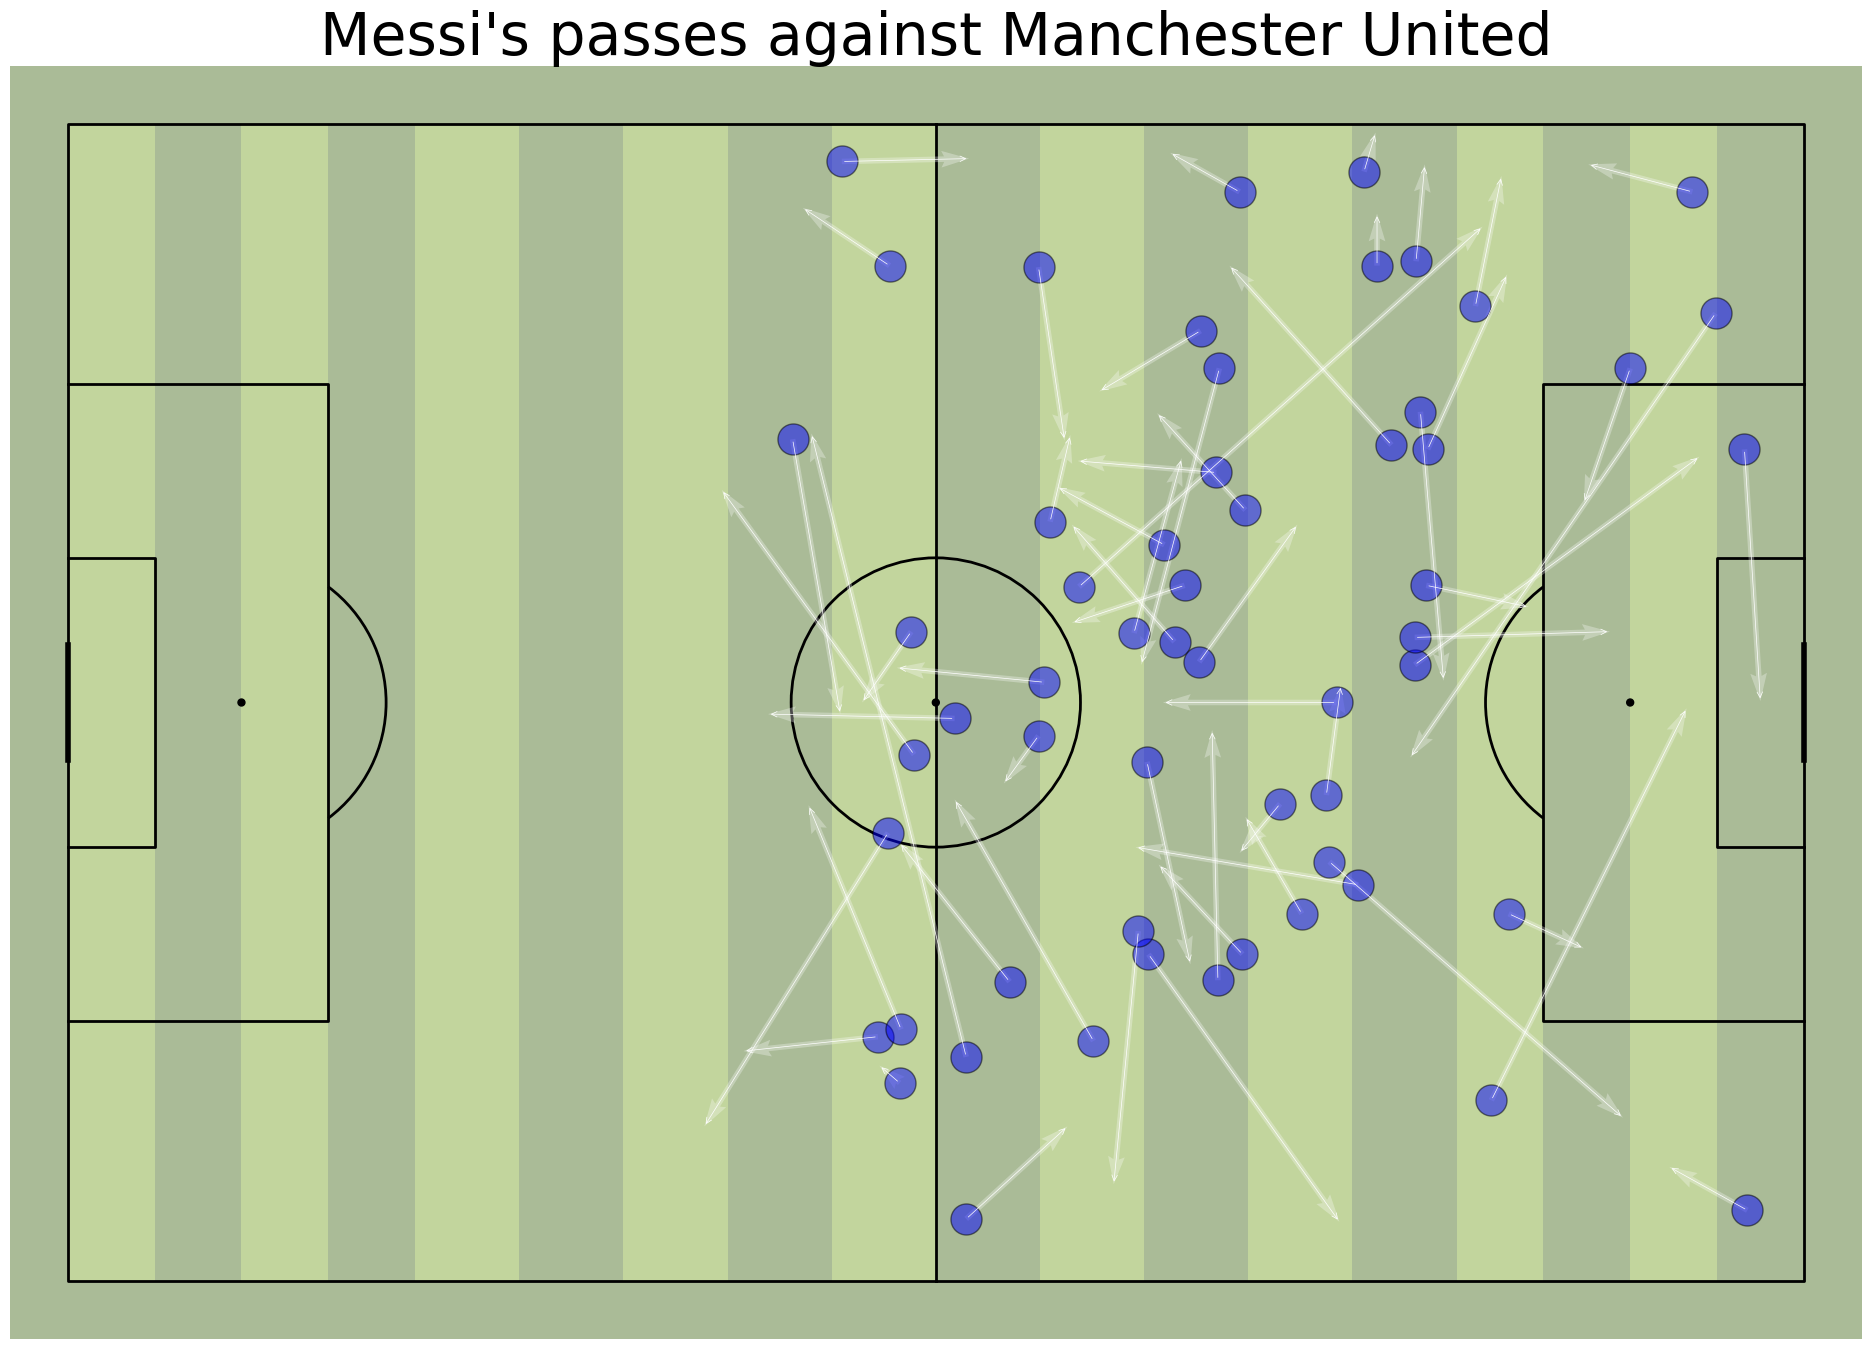

In [24]:
# Plotting Messi's Pass map
messi_filter = (df['type_name'] == 'Pass') & (df['player_name'] == "Lionel Andrés Messi Cuccittini")

df_pass = df.loc[messi_filter, ['x', 'y', 'end_x', 'end_y']]

pitch = Pitch(pitch_type='statsbomb', line_color='black', pitch_color='#aabb97', stripe_color='#c2d59d', stripe=True)

fig, ax = pitch.draw(figsize=(21, 13.6))

# Increase transparency (alpha) of pass arrows
pitch.arrows(df_pass.x, df_pass.y, df_pass.end_x, df_pass.end_y, color="white", ax=ax, alpha=0.3)

# Add labels to the arrows to indicate pass direction
for index, row in df_pass.iterrows():
    ax.annotate('', xy=(row['end_x'], row['end_y']), xytext=(row['x'], row['y']),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.5), alpha=0.3)

# Plot starting points as blue dots
pitch.scatter(df_pass.x, df_pass.y, color="blue", alpha = 0.5, s=500, edgecolors='black', ax=ax)

# Set the title
plt.title("Messi's passes against Manchester United", fontsize=42)

plt.show()

c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)


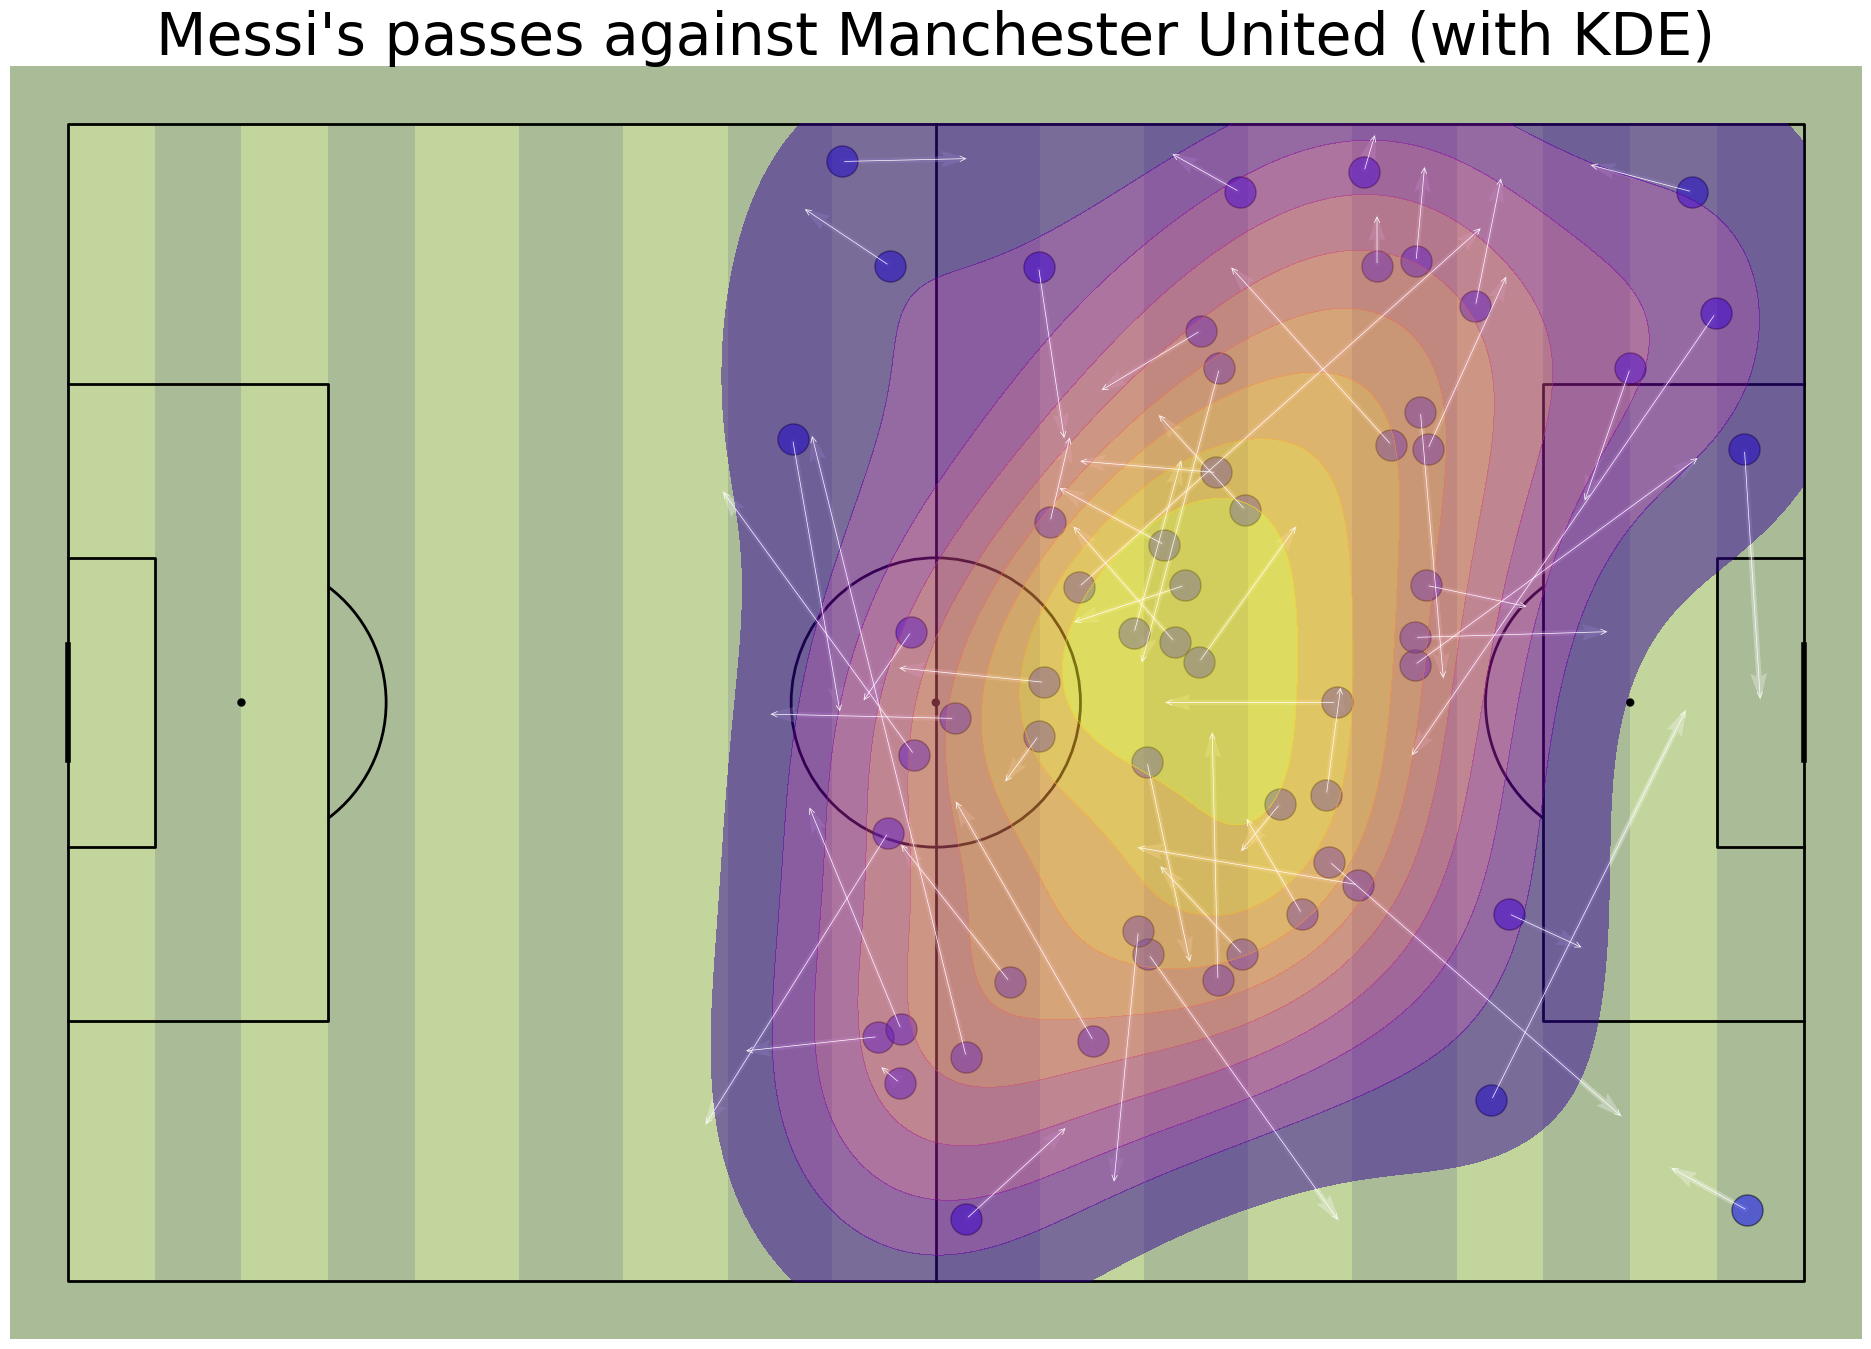

In [26]:
messi_filter = (df.type_name == 'Pass') & (df.player_name == "Lionel Andrés Messi Cuccittini")
df_pass = df.loc[messi_filter, ['x', 'y', 'end_x', 'end_y']]

pitch = Pitch(pitch_type='statsbomb', line_color='black', pitch_color='#aabb97', stripe_color='#c2d59d', stripe=True)
fig, ax = pitch.draw(figsize=(21, 13.6))

# Increase transparency (alpha) of pass arrows
pitch.arrows(df_pass.x, df_pass.y, df_pass.end_x, df_pass.end_y, color="white", ax=ax, alpha=0.3)

# Add labels to the arrows to indicate pass direction
for index, row in df_pass.iterrows():
    ax.annotate('', xy=(row['end_x'], row['end_y']), xytext=(row['x'], row['y']),
                arrowprops=dict(arrowstyle='->', color='white', lw=0.5), alpha=0.3)
    
# Plot starting points as blue dots
pitch.scatter(df_pass.x, df_pass.y, color="blue", alpha=0.5, s=500, edgecolors='black', ax=ax)

# Create the heatmap
pitch.kdeplot(
        x=df_pass['x'],
        y=df_pass['y'],
        shade=True,
        shade_lowest=False,
        alpha=0.5,
        n_levels=10,
        cmap='plasma',
        ax=ax
)

# Set the title
plt.title("Messi's passes against Manchester United (with KDE)", fontsize=42)

plt.show()

All Barcelona passes

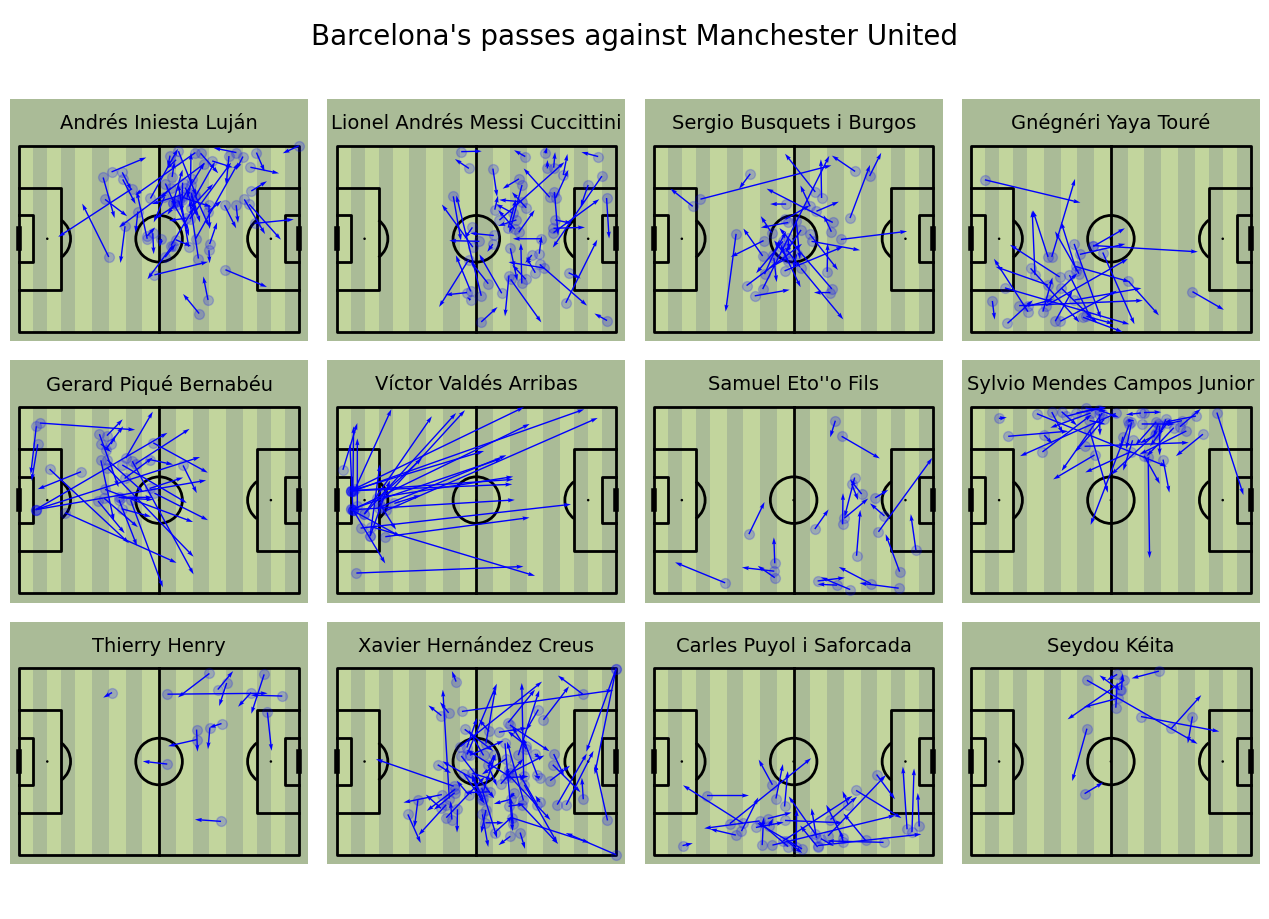

<Figure size 2100x1360 with 0 Axes>

In [28]:
# filtering to passes by Barcelona players
rm_passes = (df.type_name == 'Pass') & (df.team_name == "Barcelona") & (df.sub_type_name != "Throw-in")

# selecting only relevant columsn for the pass map
df_passes = df.loc[rm_passes, ['x', 'y', 'end_x', 'end_y', 'player_name']]

#get the list of all players who made a pass
names = df_passes['player_name'].unique()

# Draw 4x3 pitches instead of 4x4
pitch = Pitch(line_color='black', pitch_color='#aabb97', stripe_color='#c2d59d', stripe=True, pad_top=20)
fig, axs = pitch.grid(ncols=4, nrows=3, grid_height=0.85, title_height=0.06, axis=False, endnote_height=0.04, title_space=0.04, endnote_space=0.01)
plt.figure(figsize=(21, 13.6))
for name, ax in zip(names, axs['pitch'].flat[:len(names)]):
    #put player name over the plot
    ax.text(60, -10, name,ha='center', va='center', fontsize=14)
    #take only passes by this player
    player_df = df_passes.loc[df_passes["player_name"] == name]
    #scatter -  plots the player position with 0.2 alpha(visibility)
    pitch.scatter(player_df.x, player_df.y, alpha = 0.2, s = 50, color = "blue", ax=ax)
    #plot pass arrows
    pitch.arrows(player_df.x, player_df.y,
            player_df.end_x, player_df.end_y, color = "blue", ax=ax, width=1)

#We have more than enough pitches - remove them
for ax in axs['pitch'][-1, 16 - len(names):]:
    ax.remove()

#Another way to set title using mplsoccer
axs['title'].text(0.5, 0.5, "Barcelona's passes against Manchester United", ha='center', va='center', fontsize=20)
plt.show()

c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)
c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)
c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)
c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now depr

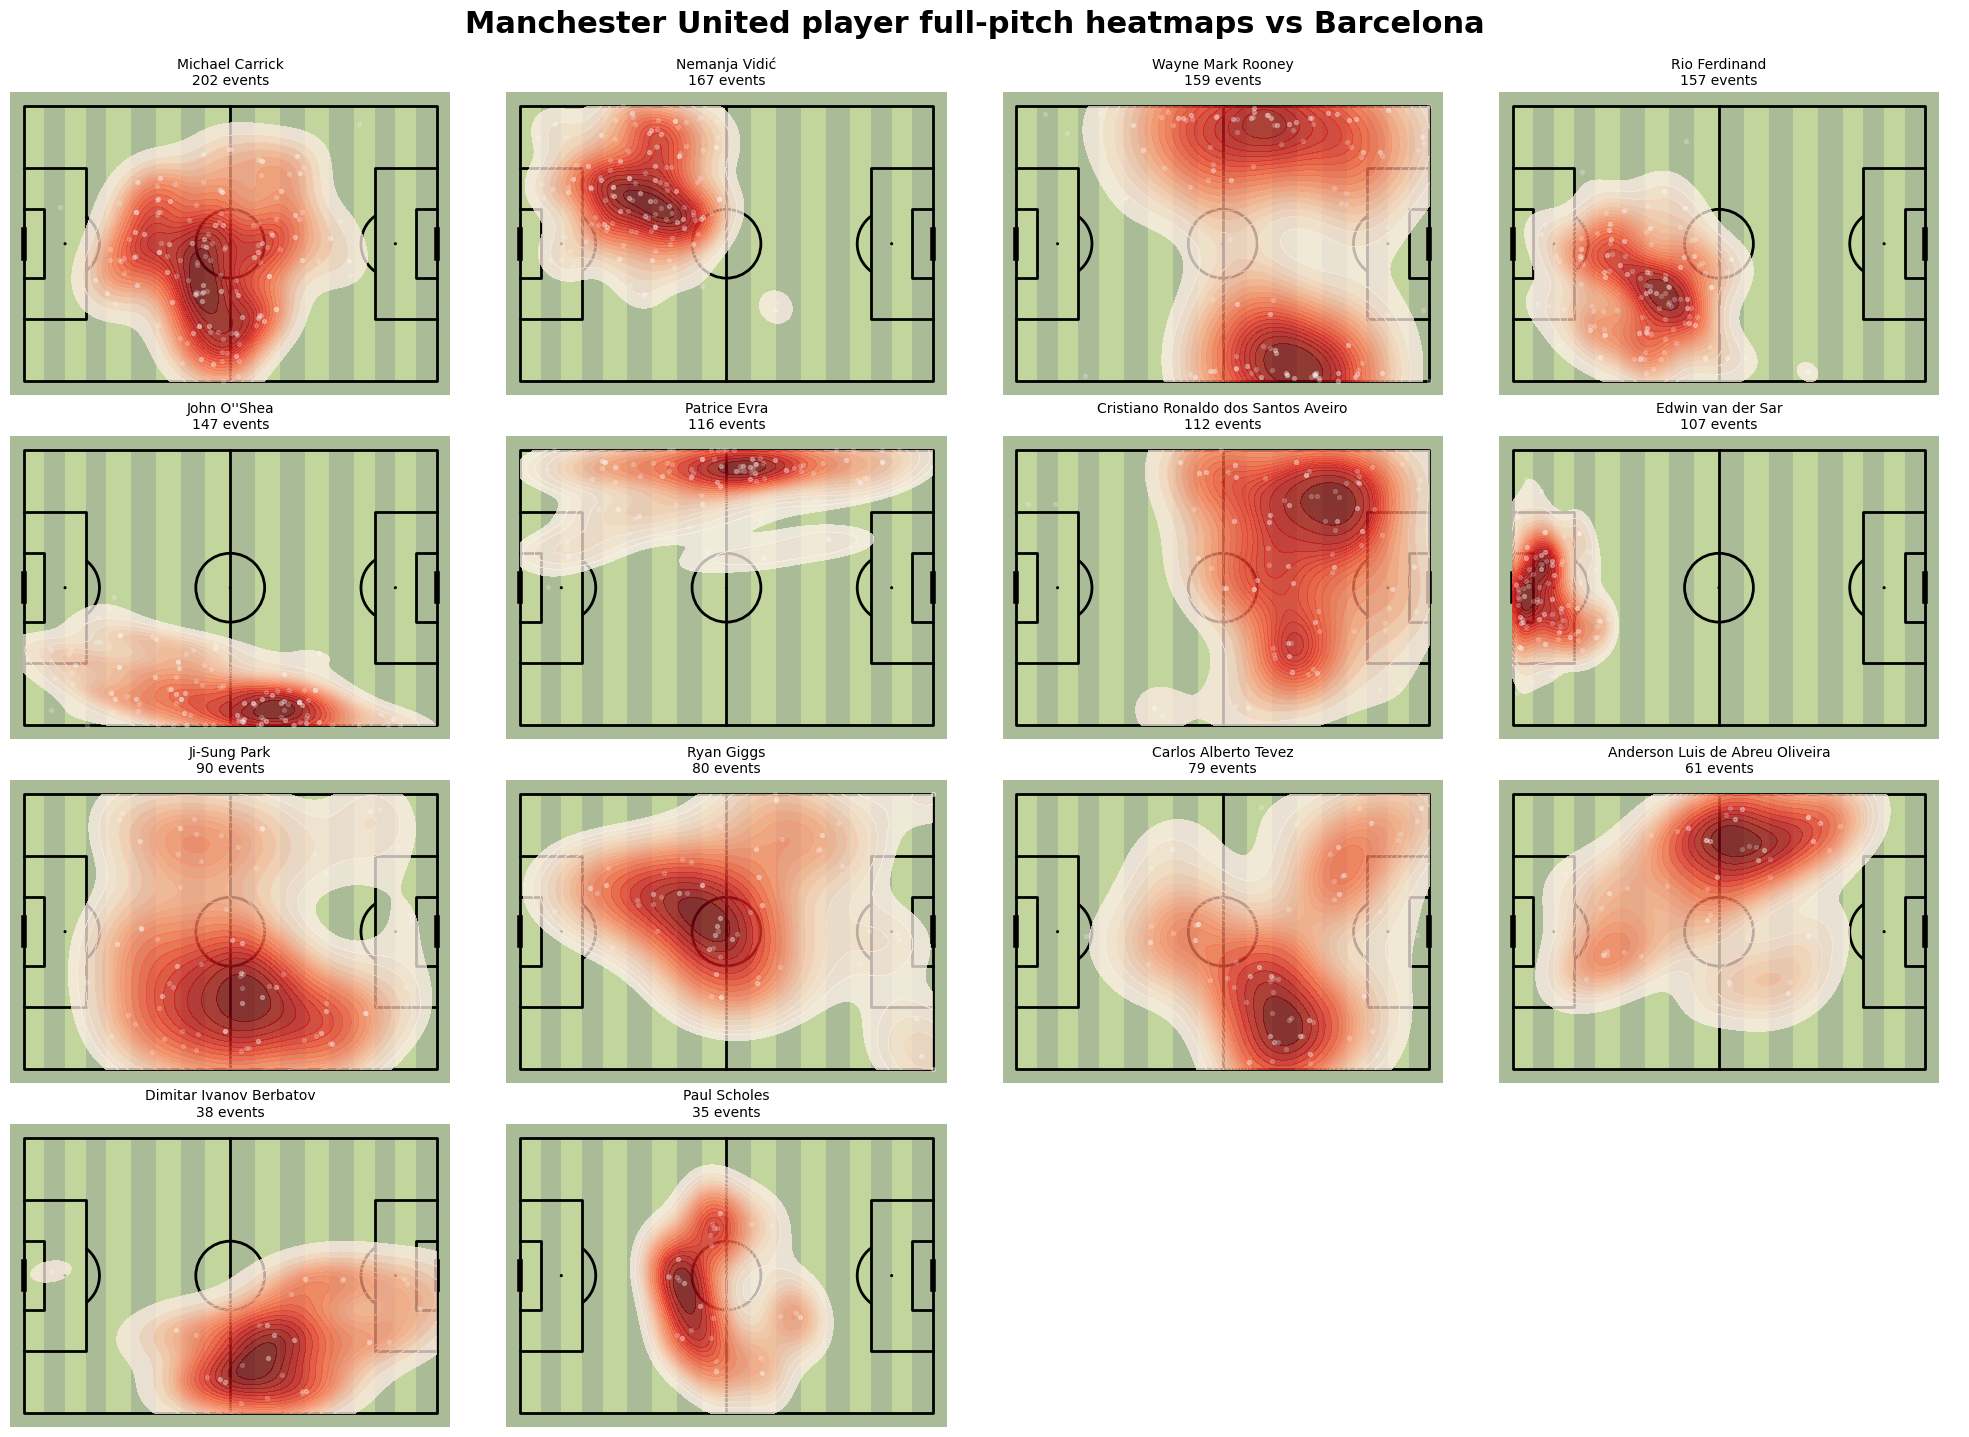

In [18]:
def plot_team_player_heatmaps(events, team_name, title=None, ncols=4, min_events_for_kde=5, cmap="magma"):
    """Plot one full-pitch event-location heatmap per player for a team."""
    team_events = (
        events.loc[
            (events["team_name"] == team_name)
            & events["player_name"].notna()
            & events["x"].notna()
            & events["y"].notna(),
            ["player_name", "x", "y"],
        ]
        .copy()
    )

    if team_events.empty:
        raise ValueError(f"No event coordinates found for team: {team_name}")

    # Put players with the most on-ball events first so the figure is easier to scan.
    player_names = team_events["player_name"].value_counts().index.tolist()
    nrows = int(np.ceil(len(player_names) / ncols))

    pitch = Pitch(
        pitch_type="statsbomb",
        line_color="black",
        pitch_color="#aabb97",
        stripe_color="#c2d59d",
        stripe=True,
    )

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5.0, nrows * 3.6))
    axes = np.asarray(axes).reshape(-1)

    for ax, player_name in zip(axes, player_names):
        player_events = team_events.loc[team_events["player_name"] == player_name]
        pitch.draw(ax=ax)

        # KDE needs enough points and some coordinate variation. If not, scatter still shows activity locations.
        can_kde = (
            len(player_events) >= min_events_for_kde
            and player_events["x"].nunique() > 1
            and player_events["y"].nunique() > 1
        )

        if can_kde:
            try:
                pitch.kdeplot(
                    x=player_events["x"],
                    y=player_events["y"],
                    shade=True,
                    shade_lowest=False,
                    alpha=0.75,
                    n_levels=20,
                    cmap=cmap,
                    ax=ax,
                )
            except Exception:
                pitch.scatter(player_events["x"], player_events["y"], s=18, alpha=0.35, color="crimson", ax=ax)
        else:
            pitch.scatter(player_events["x"], player_events["y"], s=18, alpha=0.35, color="crimson", ax=ax)

        pitch.scatter(player_events["x"], player_events["y"], s=8, alpha=0.18, color="white", ax=ax)
        ax.set_title(f"{player_name}\n{len(player_events)} events", fontsize=10)

    for ax in axes[len(player_names):]:
        ax.axis("off")

    fig.suptitle(title or f"{team_name} player full-pitch heatmaps", fontsize=22, fontweight="bold", y=0.995)
    fig.tight_layout()
    plt.show()


plot_team_player_heatmaps(
    df,
    team_name="Manchester United",
    title="Manchester United player full-pitch heatmaps vs Barcelona",
    ncols=4,
    cmap="Reds",
)

c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)
c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)
c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  return sns.kdeplot(x=x, y=y, ax=ax, clip=self.kde_clip, **kwargs)
c:\Users\Liuhy\anaconda3\Lib\site-packages\mplsoccer\_pitch_base.py:784: FutureWarning: 

`shade` is now depr

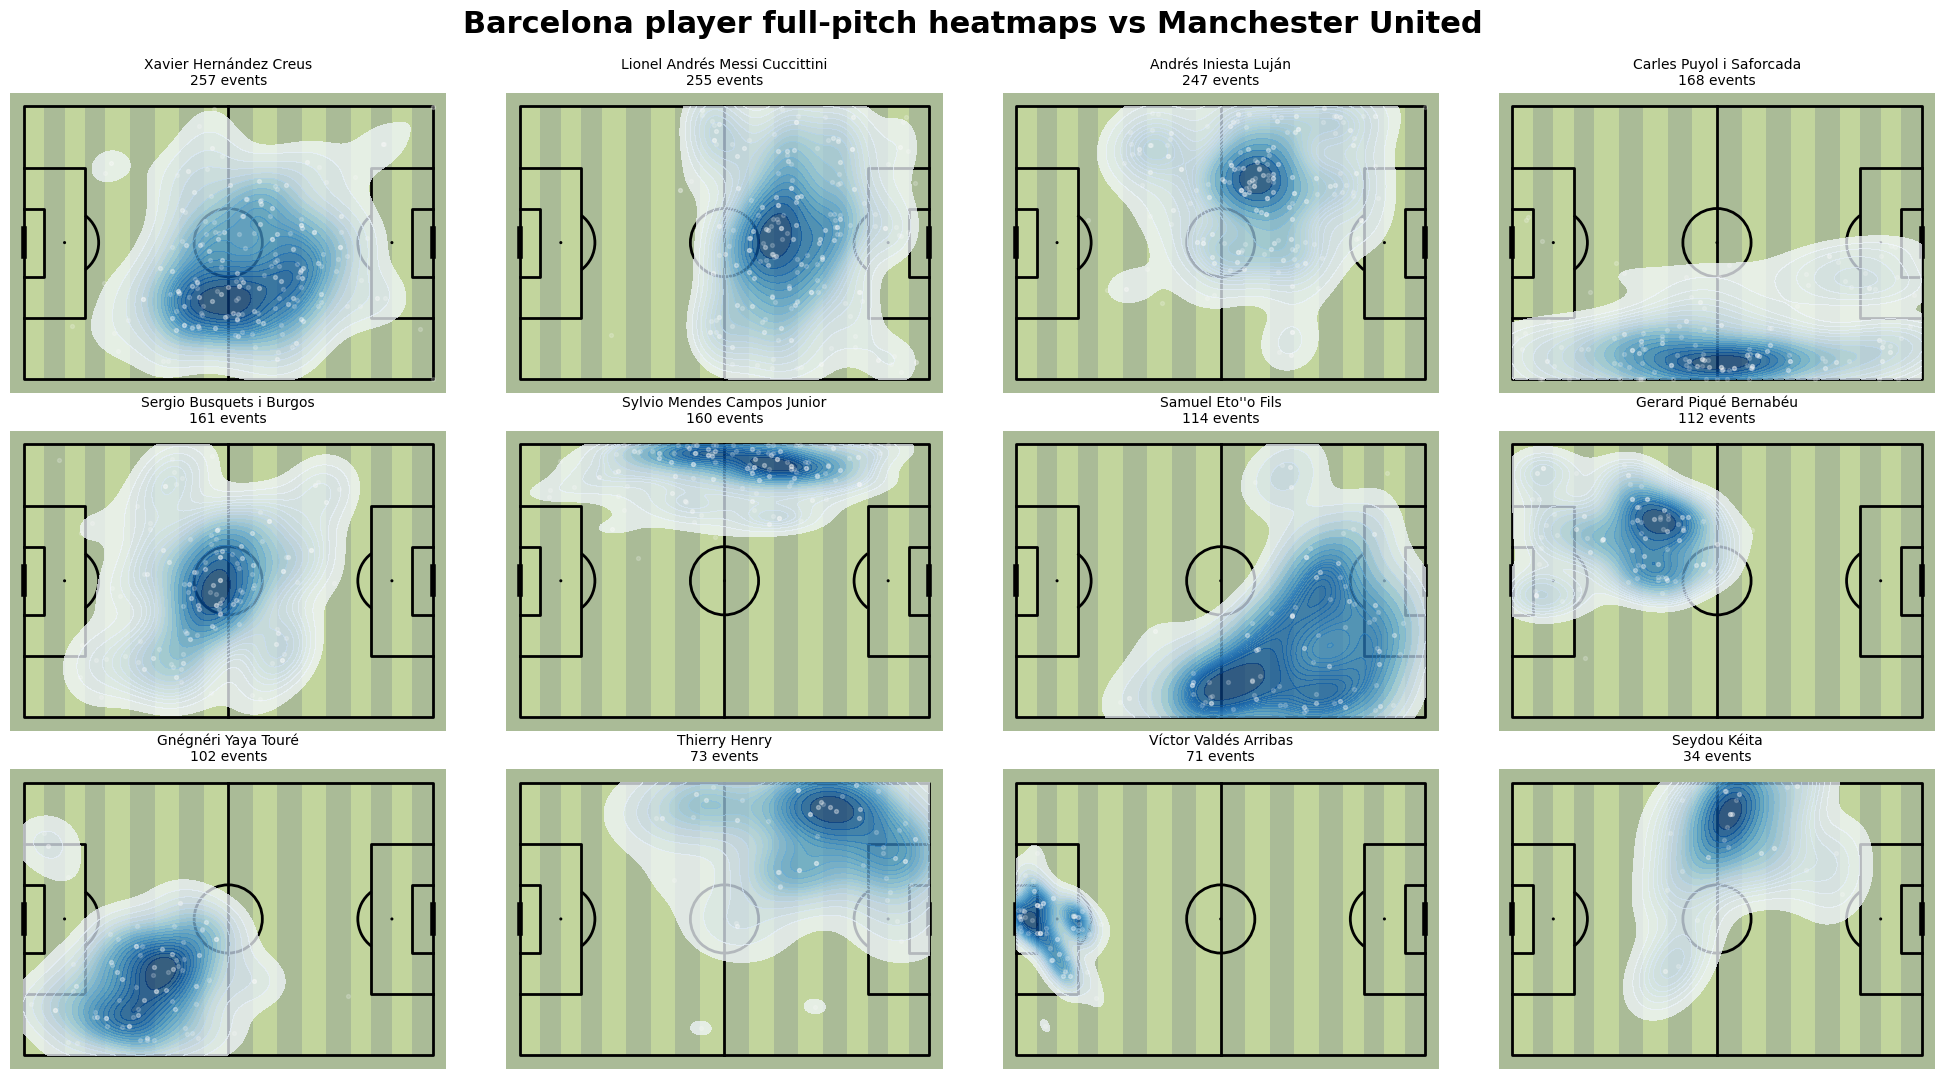

In [19]:
plot_team_player_heatmaps(
    df,
    team_name="Barcelona",
    title="Barcelona player full-pitch heatmaps vs Manchester United",
    ncols=4,
    cmap="Blues",
)